In [1]:
# In this notebook we will look at how not to intialize weight values

In [2]:
# Let's now load the necessary libaries and prepare the dataset for the cases

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout,Dense,Input

In [8]:
X,y = make_moons(
                    n_samples=250,
                    noise = 0.22,
                    random_state = 12
)

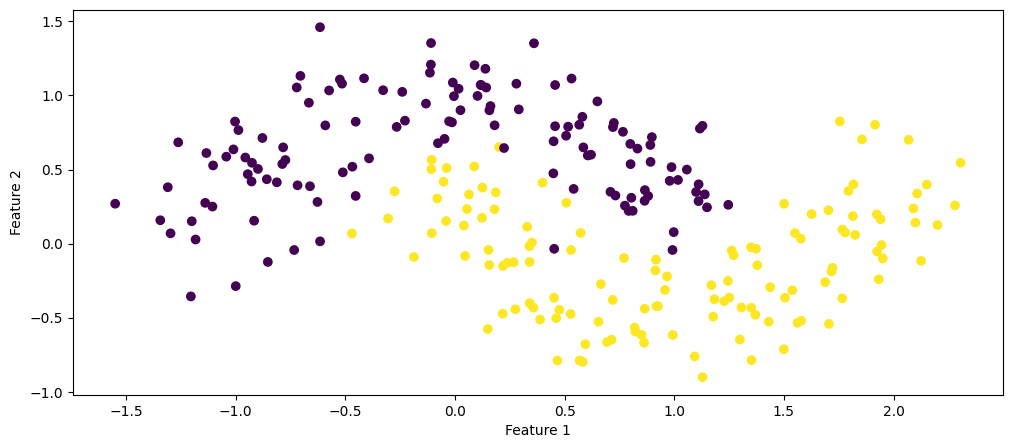

In [9]:
# Now lets plot this data to understand it better
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [ ]:
# Split the dataset 
X_train ,X_test ,y_train ,y_test = train_test_split(
                                                        X,y,
                                                        test_size = 0.2,
                                                        random_state = 9
)

# CASE 1 : Initialize with weights equal to 0

In [19]:
# FOR all the cases we will use a special function which does all the steps for us but we we only pass the activation function
# used for the hidden layers and the output layer 

def weight_initialization_zero(af_hidden,af_output,n_layers,neurons_per_layer,loss_function,metric_score):
    
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))

    for _ in range(n_layers):
        model.add(Dense(neurons_per_layer,activation=af_hidden))
    
    model.add(Dense(1,activation=af_output))

    print(model.summary())

    initial_weights = model.get_weights()

    zero_weights = [np.zeros_like(w) for w in initial_weights]
    model.set_weights(zero_weights)

    print(f'The initial model weights set to  : \n {model.get_weights()} \n ')

    model.compile(loss=loss_function,optimizer='adam',metrics=metric_score)

    history = model.fit( X,y,epochs=100,validation_data = (X_test,y_test),verbose=0)

    # Plot the loss across epochs
    print(f'The model weights after fitting are  : \n {model.get_weights()} \n ')

    print(f'The loss across epoch is   :  \n ')
    
    plt.figure(figsize=(15,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f'The decision boundary made by the model :  \n ')

    plt.figure(figsize=(15,5))
    plot_decision_regions(X_test, y_test.ravel().astype(int), clf = model, legend=2)
    plt.show()



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32), array([0.], dtype=float32)] 
 
The model weights after fitt

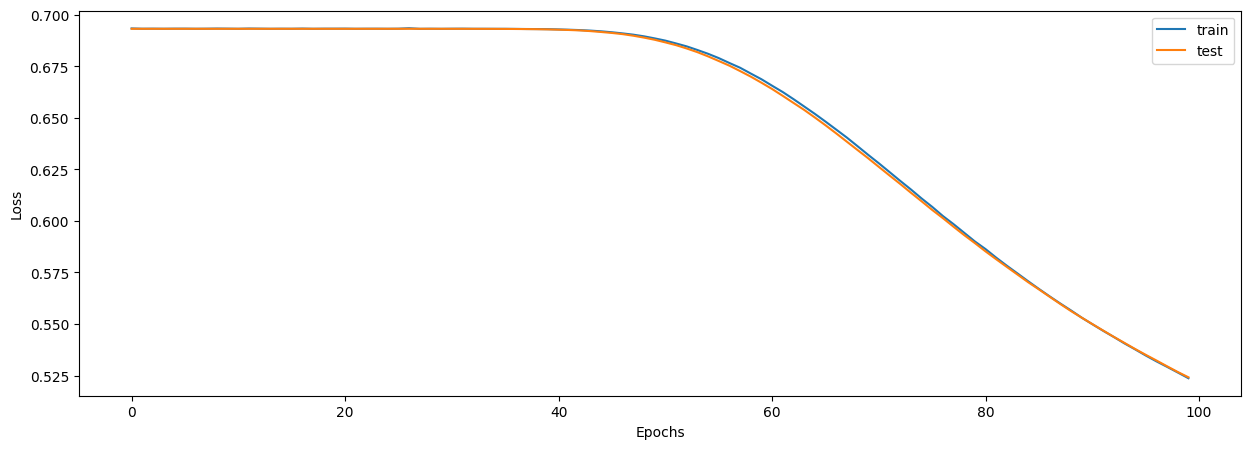

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 44s 2ms/step


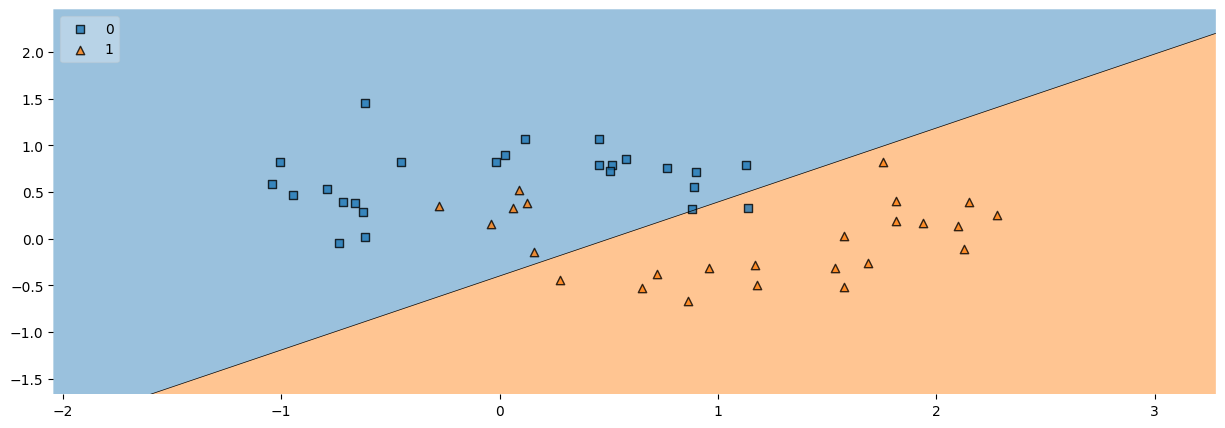

In [20]:
weight_initialization_zero(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'sigmoid',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [ ]:
'''
Mathematical Blind Spot: Initial zero-weights force \(\text{sigmoid}(0) = 0.5\), locking the initial loss at pure guesswork (0.693).
Extremely weak initial gradients trap the Adam optimizer on a flat plateau for nearly 45 epochs before it builds momentum.
Symmetric Collapse: Because every hidden neuron receives the exact same gradient,
   all 10 neurons update to the exact same final weights (e.g., 1.1136198)
10-neuron layer collapses into 1 functional neuron, breaking the model's ability to learn non-linear patterns.
'''

In [22]:
# Now we will use tanh as activation function

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32), array([0.], dtype=float32)] 
 
The model weights after fitt

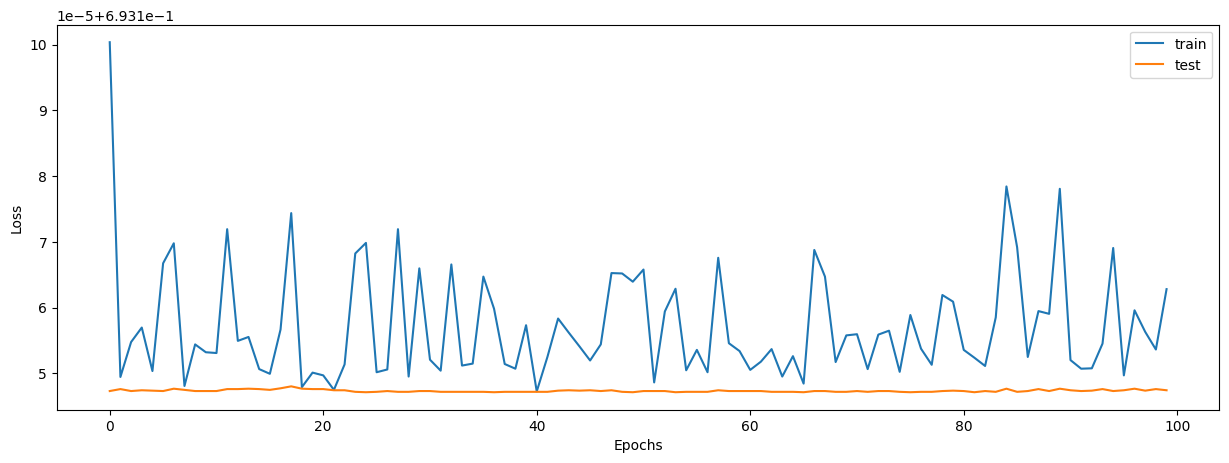

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 74s 3ms/step


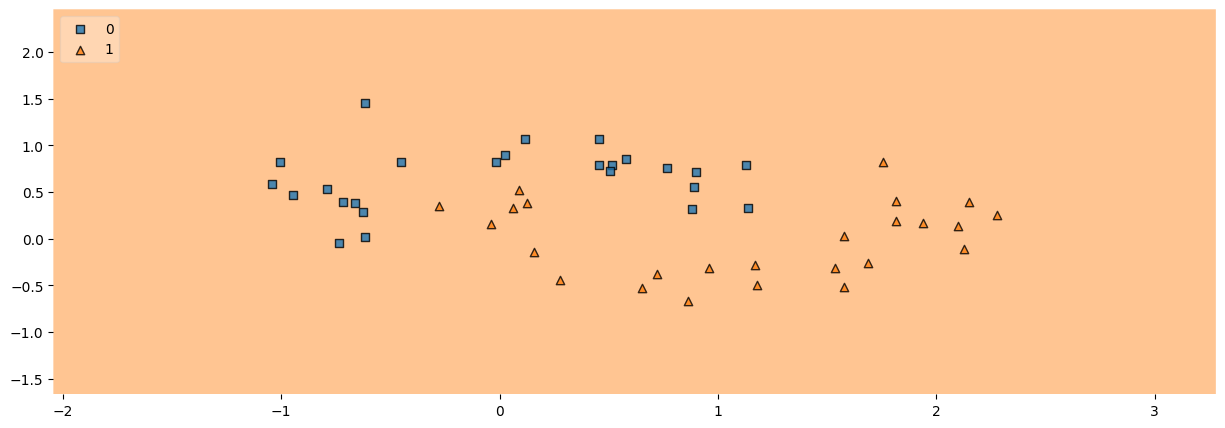

In [23]:
weight_initialization_zero(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'tanh',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [ ]:
'''
The Tanh / ReLU Failure Summary

    Absolute Gradient Death: Because (f(0) = 0), forward signals and backward gradients hit an absolute zero.
    Permanent Weight Paralysis: Hidden weights are completely unable to update, remaining frozen at 0.0 forever.
    Microscopic Micro-Ripples: Only the final output bias updates slightly, creating tiny deceptive ripples around 0.6931.
    Total Classification Blindness: The decision boundary collapses into a solid, single-color block with zero ability to separate classes

'''

In [26]:
# A similar result will be found when using relu , let's check it out 

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32), array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]], dtype=float32), array([0.], dtype=float32)] 
 
The model weights after fitt

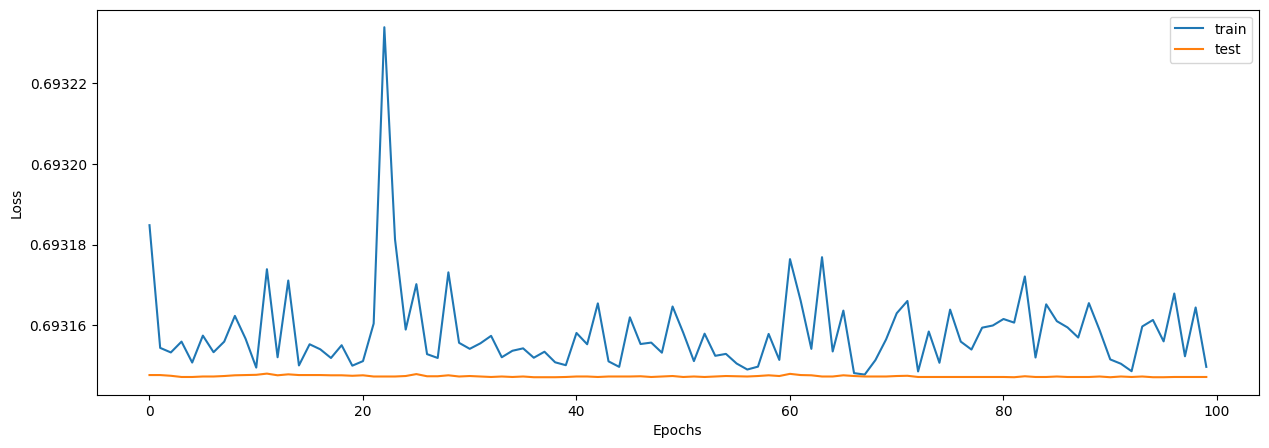

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 66s 3ms/step


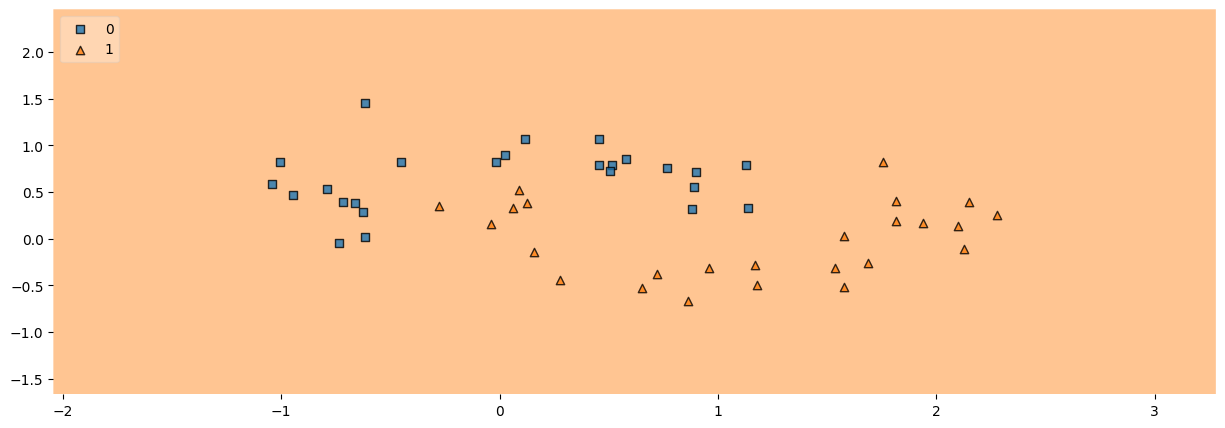

In [27]:
weight_initialization_zero(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'relu',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [28]:
# As expected similar to tanh

# CASE 1 : Initialize weights with a constant value k = 0.5

In [ ]:
# SAME FUNCTION but we initialize now with 0.5 

def weight_initialization_half(af_hidden,af_output,n_layers,neurons_per_layer,loss_function,metric_score):
    
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))

    for _ in range(n_layers):
        model.add(Dense(neurons_per_layer,activation=af_hidden))
    
    model.add(Dense(1,activation=af_output))

    print(model.summary())

    initial_weights = model.get_weights()

    half_weights = [np.ones_like(w)*0.5 for w in initial_weights]
    model.set_weights(half_weights)

    print(f'The initial model weights set to  : \n {model.get_weights()} \n ')

    model.compile(loss=loss_function,optimizer='adam',metrics=metric_score)

    history = model.fit( X,y,epochs=100,validation_data = (X_test,y_test),verbose=0)

    # Plot the loss across epochs
    print(f'The model weights after fitting are  : \n {model.get_weights()} \n ')

    print(f'The loss across epoch is   :  \n ')
    
    plt.figure(figsize=(15,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f'The decision boundary made by the model :  \n ')

    plt.figure(figsize=(15,5))
    plot_decision_regions(X_test, y_test.ravel().astype(int), clf = model, legend=2)
    plt.show()



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.

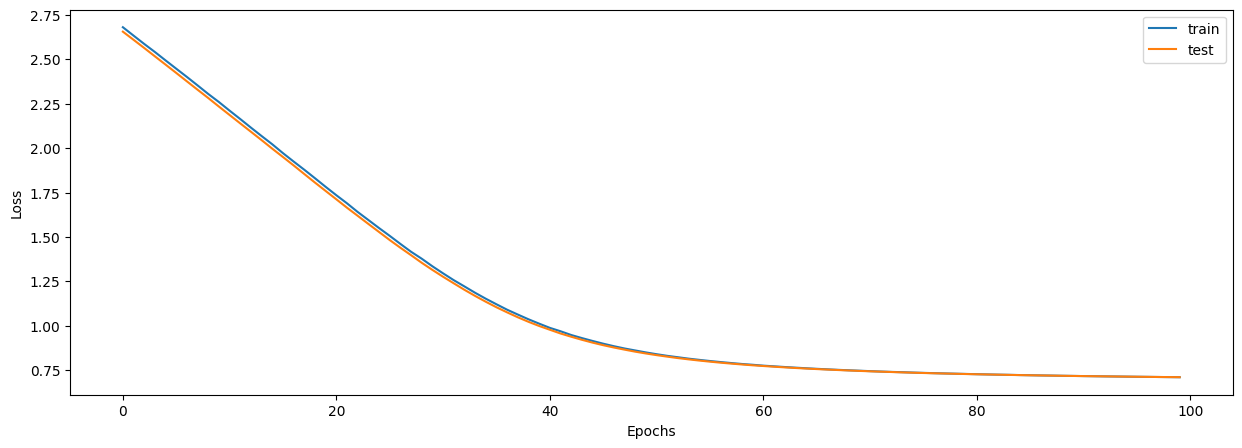

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 73s 3ms/step


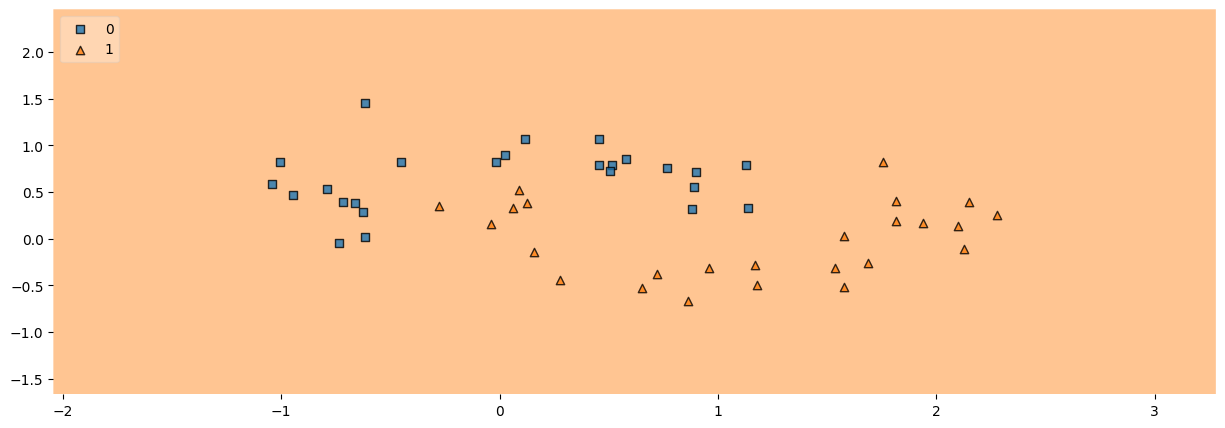

In [30]:
weight_initialization_half(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'sigmoid',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.

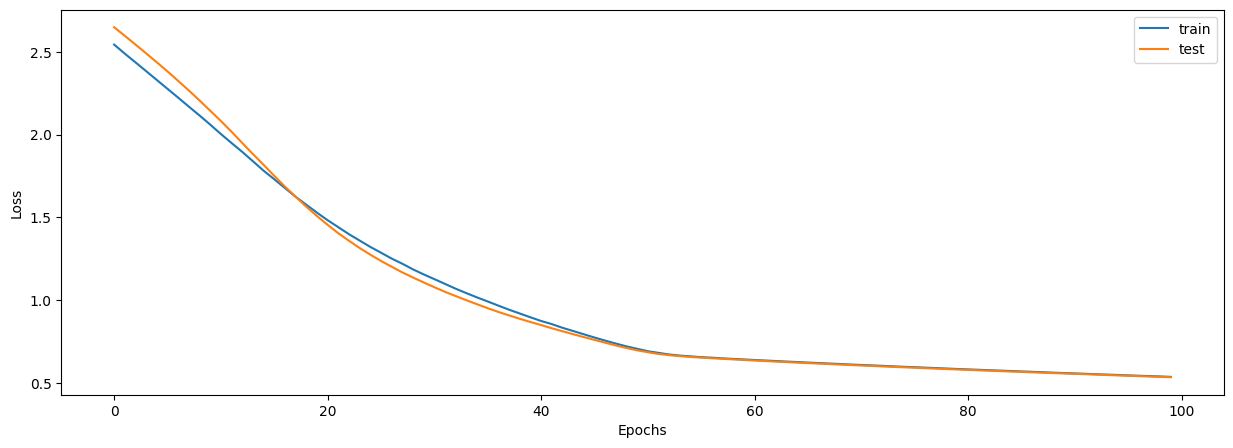

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 102s 4ms/step


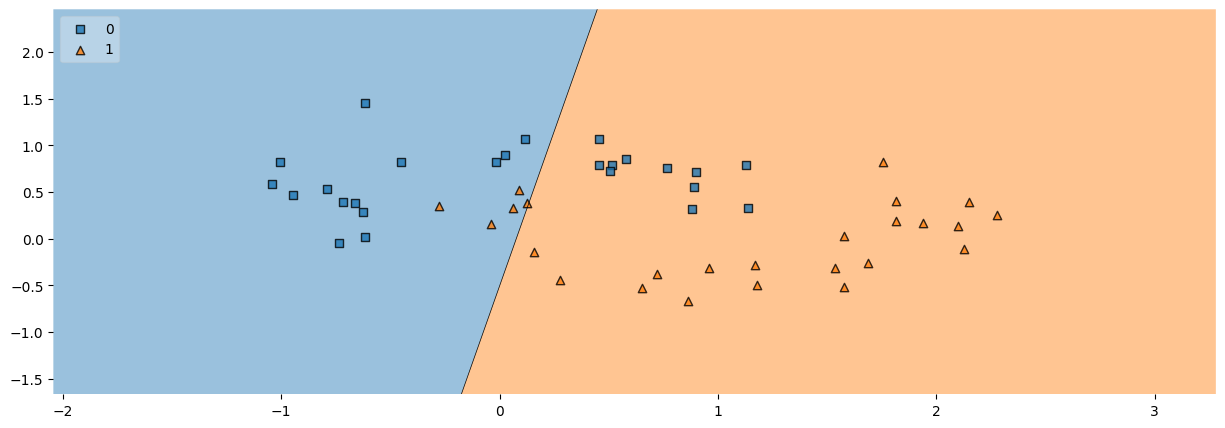

In [31]:
weight_initialization_half(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'tanh',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]], dtype=float32), array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5], dtype=float32), array([[0.5],
       [0.5],
       [0.5],
       [0.5],
       [0.

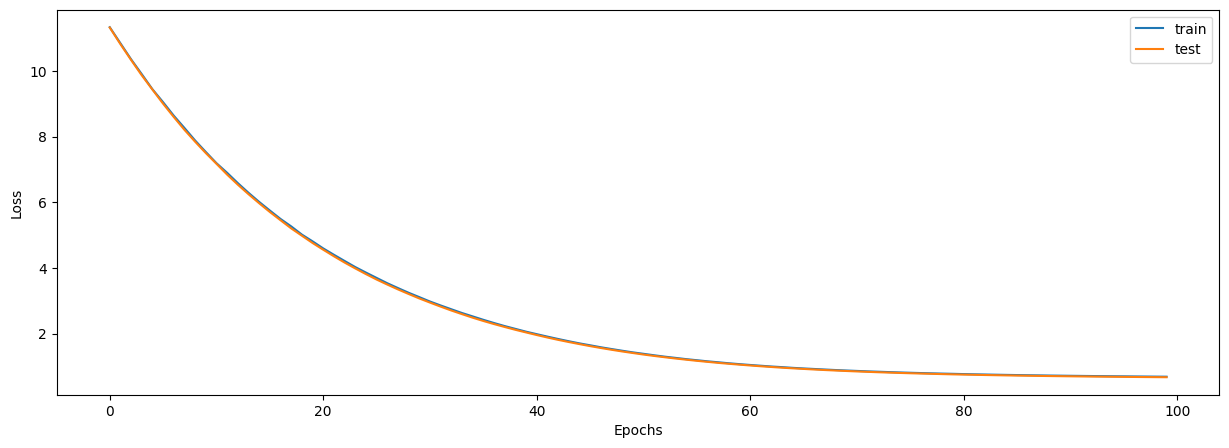

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 85s 4ms/step


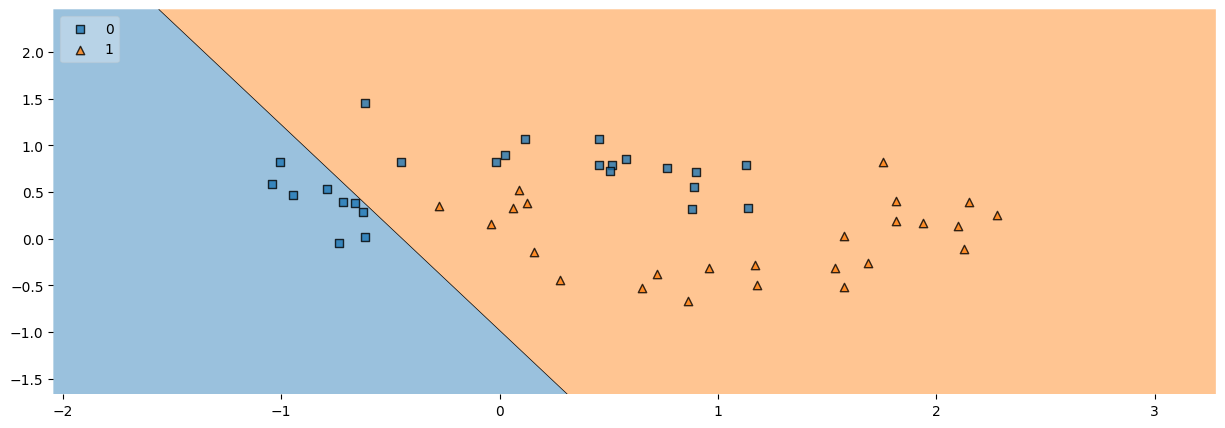

In [32]:
weight_initialization_half(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'relu',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

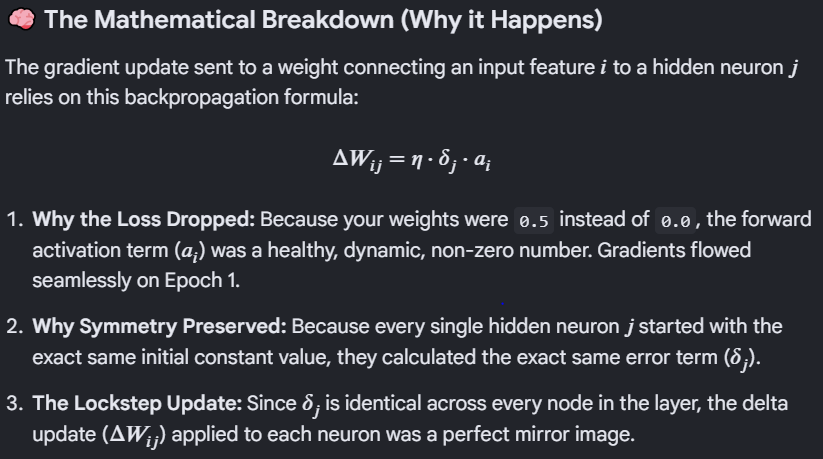

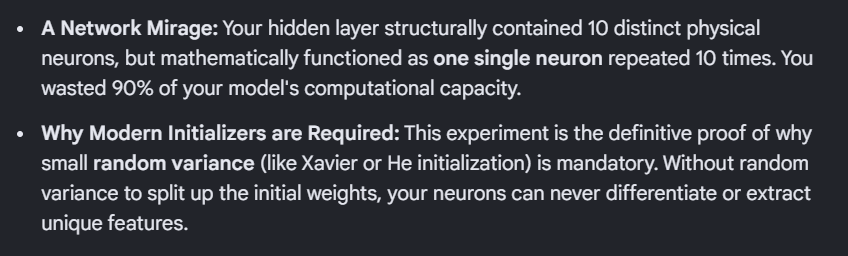

# CASE 3 : Initialize weights with smaller random weights 

In [35]:
# SAME FUNCTION but we initialize now with a small random value

def weight_initialization_small_random(af_hidden,af_output,n_layers,neurons_per_layer,loss_function,metric_score):
    
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))

    for _ in range(n_layers):
        model.add(Dense(neurons_per_layer,activation=af_hidden))
    
    model.add(Dense(1,activation=af_output))

    print(model.summary())

    initial_weights = model.get_weights()

    small_random_weights = [np.random.randn(*w.shape) * 0.01 for w in initial_weights]
    model.set_weights(small_random_weights)

    print(f'The initial model weights set to  : \n {model.get_weights()} \n ')

    model.compile(loss=loss_function,optimizer='adam',metrics=metric_score)

    history = model.fit( X,y,epochs=100,validation_data = (X_test,y_test),verbose=0)

    # Plot the loss across epochs
    print(f'The model weights after fitting are  : \n {model.get_weights()} \n ')

    print(f'The loss across epoch is   :  \n ')
    
    plt.figure(figsize=(15,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f'The decision boundary made by the model :  \n ')

    plt.figure(figsize=(15,5))
    plot_decision_regions(X_test, y_test.ravel().astype(int), clf = model, legend=2)
    plt.show()



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[ 0.00176615, -0.00525646, -0.00624088,  0.00141457,  0.00740233,
         0.00136389, -0.00652198, -0.01134396, -0.00248948,  0.00211344],
       [-0.01074257, -0.00045737, -0.00489036,  0.02043419, -0.0033362 ,
         0.00513577,  0.00906752,  0.00672405,  0.01224835, -0.00181434]],
      dtype=float32), array([ 0.01264221, -0.00816478, -0.01246702, -0.00398694,  0.00641154,
        0.00310968,  0.01076847,  0.00316513,  0.00574242, -0.00150569],
      dtype=float32), array([[-0.00010362, -0.00917654, -0.00514303, -0.00232821,  0.00390627,
        -0.00204347, -0.00308716,  0.0070234 , -0.00988244,  0.00081805],
       [-0.00917043, -0.0108526 ,  0.00418423, -0.00748665, -0.00964155,
         0.00176222,  0.00760062,  0.00279366, -0.00762888,  0.00280932],
       [-0.00791142, -0.00087658,  0.01276808, -0.00516921, -0.01157182,
        -0.01586383,  0.00359979, -0.01554986, -0.00024875,  0.00490968],
       [-0.02600813,  0.0020281

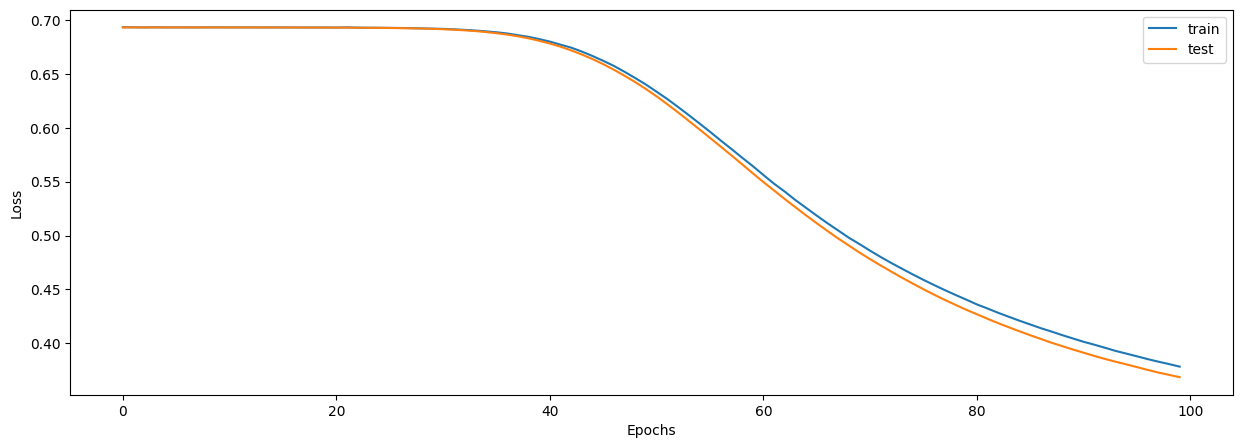

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 81s 3ms/step


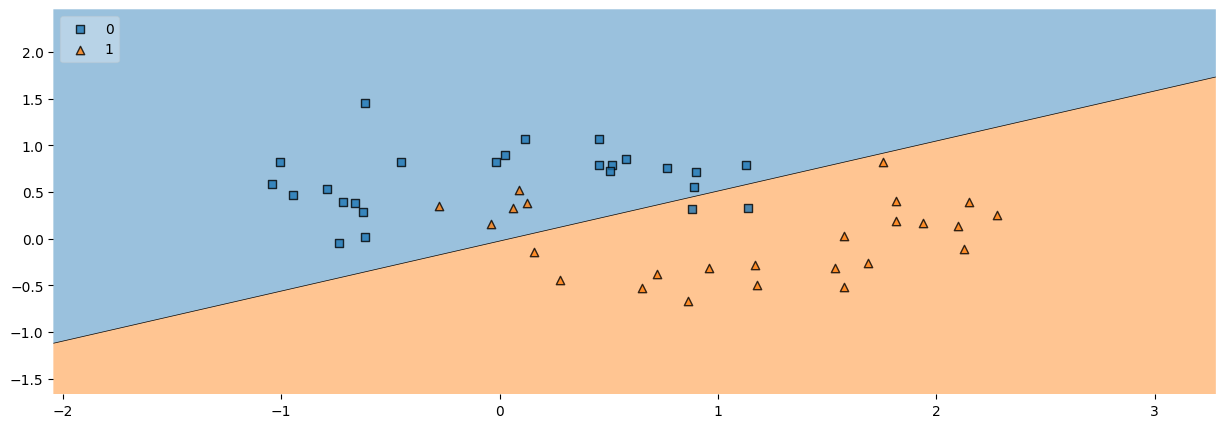

In [36]:
weight_initialization_small_random(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'sigmoid',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [37]:
# Here we change our strategy because we understand that initializing weights with any constant k is not gonna work.
# Hence we switch to initialzing with random values and first we initialize with small random values for sigmoid 

In [ ]:
'''
While scaling the standard deviation by a hardcoded 0.01 successfully breaks symmetry, 
it highlights why a static constant multiplier fails to scale dynamically across different networks:

If you keep * 0.01 but scale your network architecture up to 10 hidden layers (n_layers=10), 
the small weights will pass a signal that gets smaller and smaller at each layer.

By the time the backpropagation signal marches back to Layer 1, 
it will shrink to near-zero, triggering a Vanishing Gradient slowdown.
'''

In [38]:
# This will work fine for shallow networks but again cause vanishing gradient problem on deep networks

In [39]:
# As you can see still it acts a linear model unable to capture the true escence of the data 

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[ 0.00919873, -0.00228082, -0.00351556, -0.00815378,  0.00197117,
        -0.00023282, -0.00179   ,  0.008875  , -0.00546307, -0.00072655],
       [ 0.00934099,  0.01527593, -0.00407691,  0.02820838, -0.0181058 ,
        -0.00437114, -0.00760342, -0.00203442,  0.03458378,  0.00635972]],
      dtype=float32), array([ 0.01416964,  0.0043491 , -0.00666605,  0.01284296, -0.01051207,
       -0.00776172,  0.00683   , -0.0026707 ,  0.00333756,  0.00335971],
      dtype=float32), array([[-1.05281742e-02, -3.87473940e-03,  1.45262033e-02,
         1.83783716e-03,  1.58218257e-02,  1.26584182e-02,
         1.02242818e-02, -8.06487910e-03, -3.79803847e-03,
        -9.22242925e-03],
       [-4.39089164e-03, -8.68790317e-03,  3.75358947e-03,
         5.55594452e-03,  2.07225345e-02,  3.02148703e-03,
         5.13980165e-03,  8.27875268e-03, -5.03899856e-03,
        -5.92129491e-03],
       [-7.72100082e-03, -1.05584227e-02,  7.55579164e-03,
       

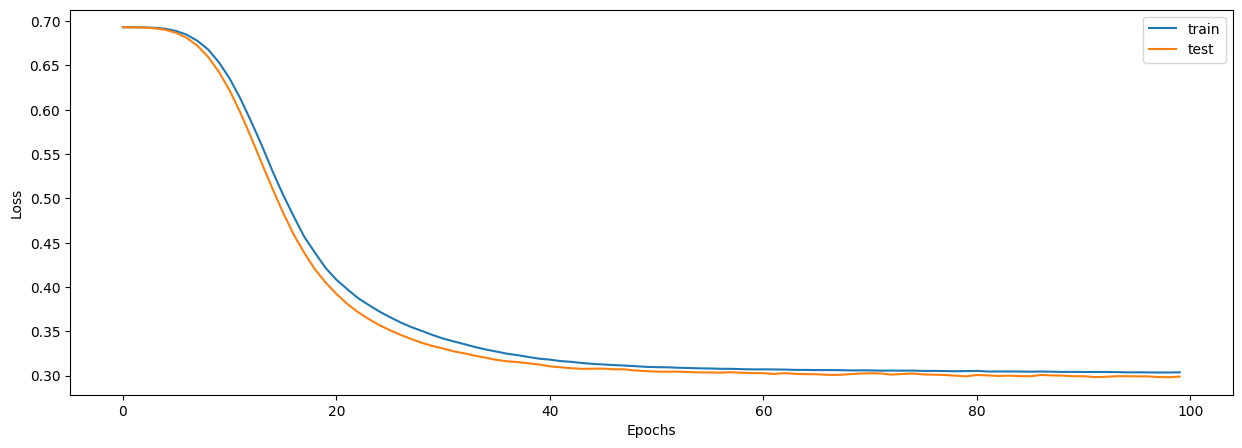

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 95s 4ms/step


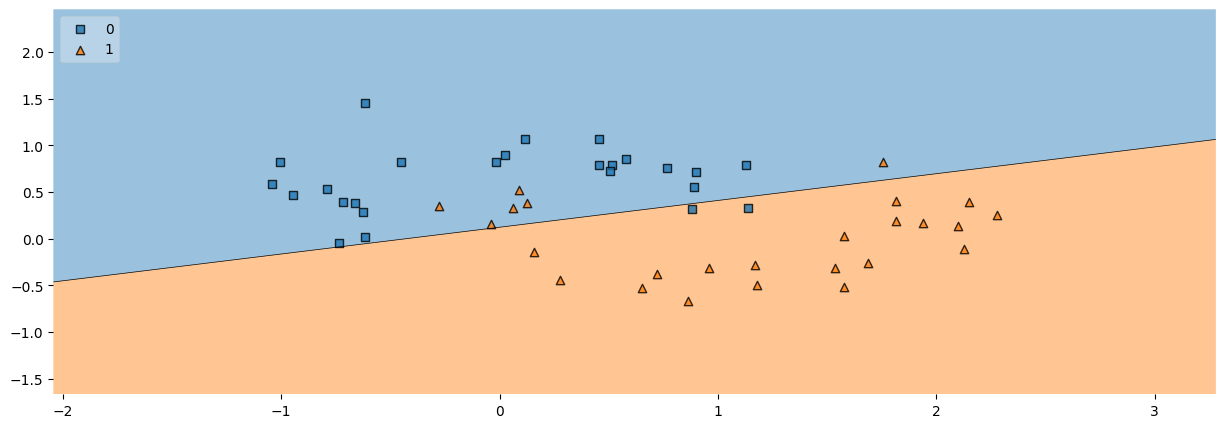

In [40]:
weight_initialization_small_random(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'tanh',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [41]:
# This causes the weight values to be closer to 0 and then causing the further layer gradient calculated during bpn to be 0
# This again leads to vanishing gradient problem and is the strongest here 

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[-0.00784789, -0.0052745 ,  0.01010333,  0.01137166,  0.01381636,
         0.00629495,  0.00166163,  0.00659142, -0.00391107, -0.00845586],
       [ 0.00197326, -0.00641785,  0.02201462, -0.00085559, -0.02336145,
         0.00391007,  0.01025614,  0.01696556, -0.00498548, -0.00957021]],
      dtype=float32), array([ 0.00703647, -0.01480687, -0.00136471, -0.00569807,  0.00929254,
        0.00904558, -0.01033003, -0.00348118, -0.00763071, -0.00983143],
      dtype=float32), array([[ 2.52680620e-03, -1.30512780e-02,  5.88467810e-03,
         4.91487188e-03, -4.23240988e-03,  1.55618982e-02,
         1.67120658e-02, -2.87226890e-03,  1.57293701e-03,
         2.33936985e-03],
       [-9.40526929e-03,  5.22157550e-03, -8.81254906e-04,
        -1.62104275e-02, -1.33940196e-02,  5.84479934e-03,
        -5.53889317e-04,  7.44652189e-03,  1.11672394e-02,
        -1.63982331e-03],
       [-3.88712552e-03,  1.47358701e-02, -1.41009444e-03,
       

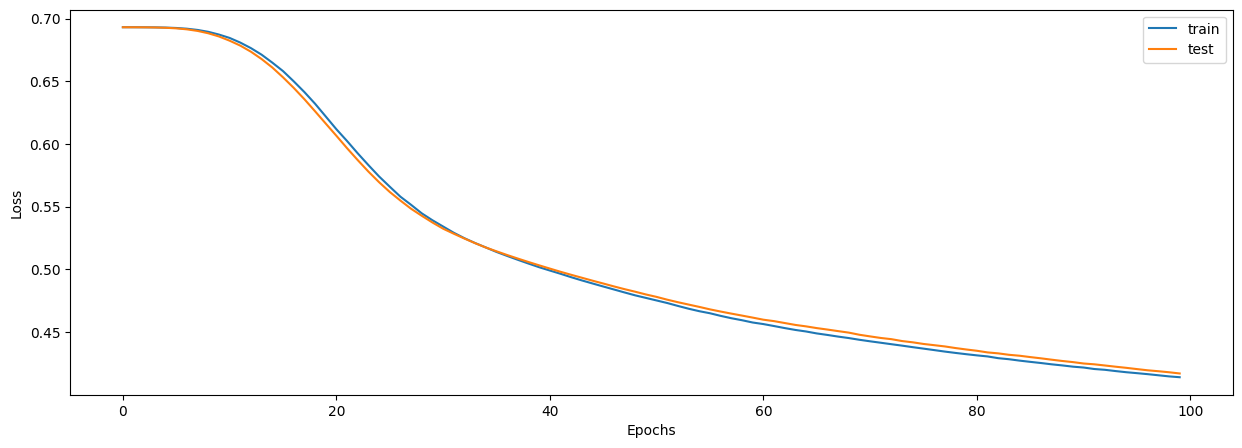

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 59s 2ms/step


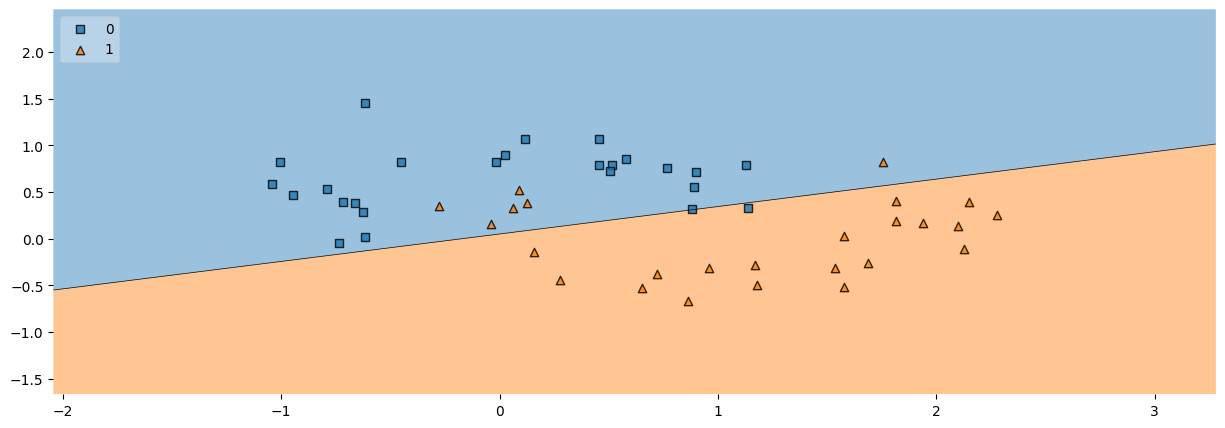

In [42]:
weight_initialization_small_random(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'relu',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [43]:
# These small values cause the convergence to be really slow in the relu and cause a high training time

In [44]:
# I researched a bit more found out that this eventual leads to the dying relu problem due to the random nature and the small scale
# More analysis given below from a gemini conversation

#### 1. The Mathematical Dead-Zone (The Dying ReLU Problem)
The ReLU function is mathematically defined as:
$$f(z) = \max(0, z)$$

Because your random initial weights are scaled tightly around zero by a factor of `0.01`, the net input ($z = Wx + b$) to the hidden layer settles near the origin. 
* **The Negative Split:** Standard normal distributions are zero-centered, meaning roughly **50% of your hidden neurons will randomly receive a negative input** ($z < 0$) on the very first forward pass.
* **Instant Death:** ReLU instantly clamps those negative signals to exactly `0.0`. 
* **Permanent Paralysis:** The derivative of ReLU for any negative input is exactly `0`. Backpropagation cannot pass weight updates through a zero gradient, rendering half of your hidden layer permanently dead from Epoch 1.

#### 2. The Exponential Shrinkage (The Layer Multiplier Cascade)
For the remaining active neurons, forcing a static `0.01` standard deviation triggers a **Vanishing Gradient** cascade across deeper layer blocks:
* **Layer 1 Output:** Inputs are scaled down by factors around `0.01`.
* **Layer 2 Output:** Already miniature fractional signals are multiplied *again* by Layer 2's `0.01` weights, collapsing the forward signal variance down toward `0.0001`.

By the time the forward pass reaches the output layer, the final error signal is microscopic. Backpropagation multiplies small weights by small activations repeatedly, sending near-zero updates ($\Delta W$) back to the early hidden layers. The network effectively stalls out and struggles to converge.

#### 3. Why It Mimics a Weak Linear Model
Because the weights are constrained to a tiny local neighborhood around $(0,0)$, the signals never push far enough up the positive activation slope to allow the multi-layered network to express its non-linear bending capacity. 

The positive side of ReLU behaves as a simple linear identity mapping ($f(z) = z$) with a constant gradient of `1`. Trapped in this micro-scale, the layer functions as a rudimentary linear combination matrix, failing to warp or curve a complex, organic decision boundary.

---


# CASE 4 : Initialize weights with large random weight [0 , 1]

In [46]:
# SAME FUNCTION but we initialize now with a large random value

def weight_initialization_large_random(af_hidden,af_output,n_layers,neurons_per_layer,loss_function,metric_score):
    
    model = Sequential()
    model.add(Input(shape=(X.shape[1],)))

    for _ in range(n_layers):
        model.add(Dense(neurons_per_layer,activation=af_hidden))
    
    model.add(Dense(1,activation=af_output))

    print(model.summary())

    initial_weights = model.get_weights()

    large_random_weights = [np.random.randn(*w.shape) * 10 for w in initial_weights]
    model.set_weights(large_random_weights)

    print(f'The initial model weights set to  : \n {model.get_weights()} \n ')

    model.compile(loss=loss_function,optimizer='adam',metrics=metric_score)

    history = model.fit( X,y,epochs=100,validation_data = (X_test,y_test),verbose=0)

    # Plot the loss across epochs
    print(f'The model weights after fitting are  : \n {model.get_weights()} \n ')

    print(f'The loss across epoch is   :  \n ')
    
    plt.figure(figsize=(15,5))
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f'The decision boundary made by the model :  \n ')

    plt.figure(figsize=(15,5))
    plot_decision_regions(X_test, y_test.ravel().astype(int), clf = model, legend=2)
    plt.show()



Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

None
The initial model weights set to  : 
 [array([[-12.013774 ,   4.4515285,  -9.193464 ,   1.6901343,  11.080271 ,
          5.7688513,   4.041199 ,  -4.1684856,  -7.3731976,   3.070319 ],
       [  1.5889015, -23.062994 ,  -9.679159 ,   5.424122 ,  -2.96372  ,
         -1.030545 ,  -4.922051 ,  -2.0608573,   9.587526 ,  -1.7178602]],
      dtype=float32), array([  7.535674 ,  -9.462499 ,  -8.466331 ,  17.877708 ,  -1.0710388,
       -18.446186 ,  -5.101301 , -14.914428 ,   3.9432588,   2.6902442],
      dtype=float32), array([[  1.1790779 ,  17.031982  ,   7.2148423 ,  -2.156386  ,
         13.268708  ,   1.9533424 ,   0.77675563, -14.896531  ,
         -6.3986974 ,  -5.436131  ],
       [ -8.1426735 ,   1.4819865 ,  -3.922485  ,  -5.5713    ,
          4.6695046 ,  14.908735  ,  12.279388  ,  -9.935405  ,
          0.8036501 ,   4.430967  ],
       [ -2.6719437 ,   9.3638735 ,   8.986487  ,  -8.514204  ,
          4.2911663 , -10.924952  ,  -0.6444525 ,  -2.700715  ,
          3.88

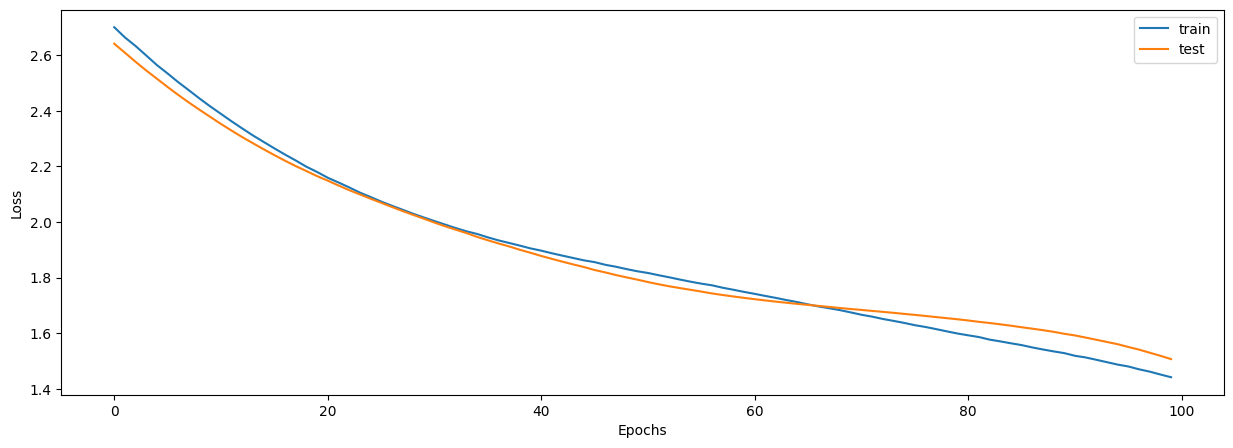

The decision boundary made by the model :  
 
23438/23438 ━━━━━━━━━━━━━━━━━━━━ 99s 4ms/step


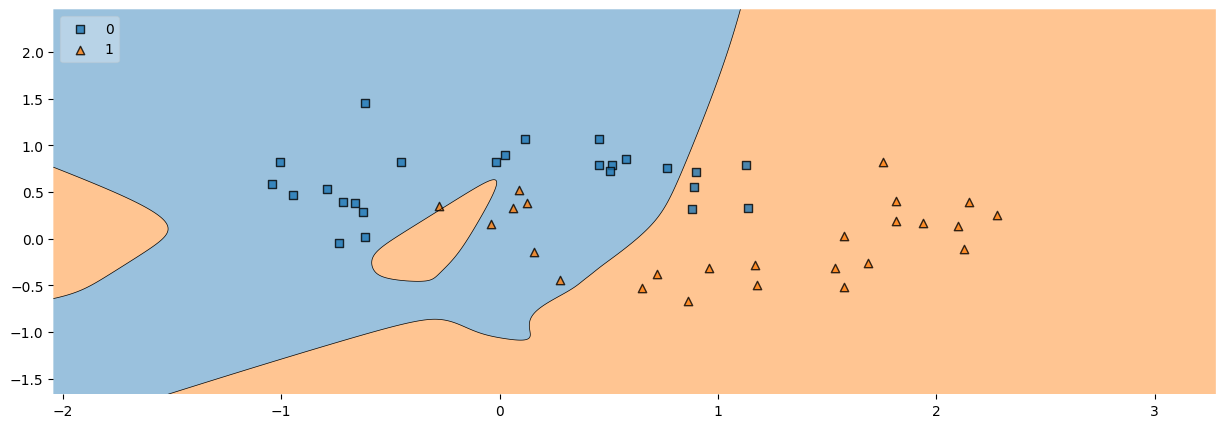

In [47]:
weight_initialization_large_random(
                                neurons_per_layer = 10,
                                n_layers=2,
                                af_hidden = 'sigmoid',
                                af_output = 'sigmoid',
                                loss_function = 'binary_crossentropy',
                                metric_score = ['accuracy']
        
)

In [ ]:
'''
The Anatomy of the Island Boundary (Large Weights + Sigmoid):

    Zero Slope Everywhere: Large weights push the network inputs deep into the Sigmoid plateaus where the  < -- Main cause for everything
    derivative is strictly \(0\) (not \(1\)).
    
    Hard Binary Mapping: This forces the hidden layer to behave like a series of harsh digital switches, 
    outputting raw \(0.0\)s or \(1.0\)s.
    
    Frozen Artifacts: The final chaotic shapes and isolated islands are the un-optimized intersections 
    of these hard digital cuts. Because the gradients are zeroed out by the plateaus, 
    the model is completely paralyzed and cannot smooth these random shapes into a proper decision boundary.


'''

In [49]:
# As we can see that this grealy reduced the model performance a lot